# Q10 — Are multi-platform restaurants rated differently? (selection effect) *(extended)*

Tests whether simply *being listed on more platforms* is associated with higher ratings and
more reviews — a visibility/selection effect — using Google's rating as the common yardstick
(present for every venue).

In [1]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


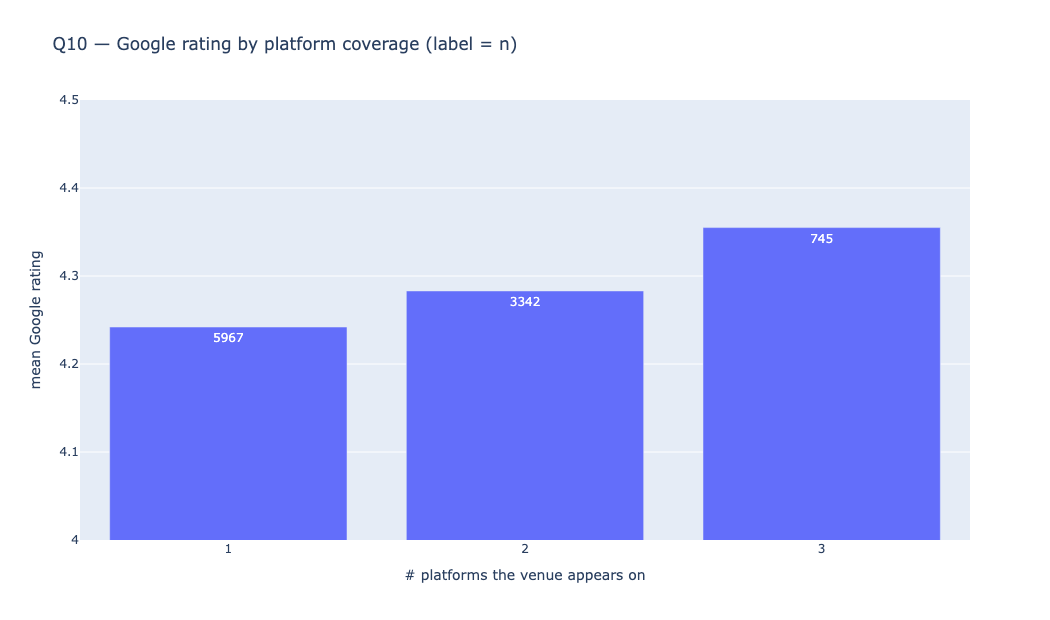

,platform_count,restaurants,mean_google_rating,median_google_reviews
0,1,5967,4.242,83.0
1,2,3342,4.283,371.0
2,3,745,4.355,548.0


In [2]:
q10a = publish(run(queries.q10_rating_by_coverage()), "q10_rating_by_coverage",
               "Q10 — Google rating and review volume by number of platforms a venue is on.")
fig = px.bar(q10a, x="platform_count", y="mean_google_rating", text="restaurants",
             labels={"platform_count": "# platforms the venue appears on", "mean_google_rating": "mean Google rating"},
             title="Q10 — Google rating by platform coverage (label = n)")
fig.update_yaxes(range=[4.0, 4.5])
fig.show()
q10a

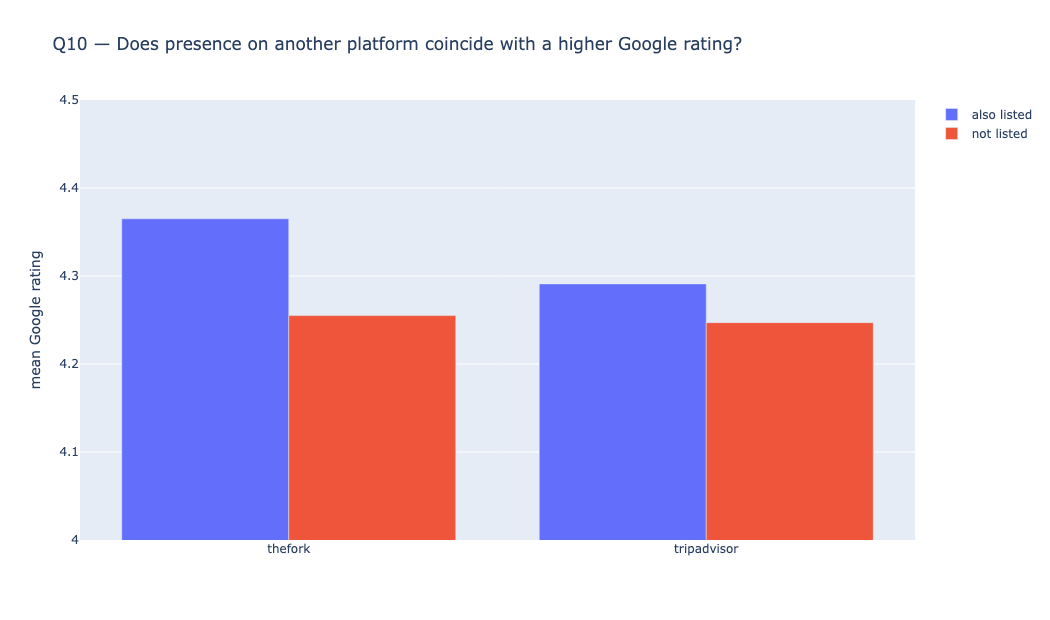

,other_platform,bucket,restaurants,mean_google_rating,median_google_reviews
0,thefork,also listed,908,4.365,484.0
1,thefork,not listed,9146,4.255,154.0
2,tripadvisor,also listed,3924,4.291,409.0
3,tripadvisor,not listed,6130,4.247,85.0


In [3]:
q10b = publish(run(queries.q10_rating_by_presence()), "q10_rating_by_presence",
               "Q10 — Google rating/volume by presence on each other platform.")
fig = px.bar(q10b, x="other_platform", y="mean_google_rating", color="bucket", barmode="group",
             labels={"other_platform": "", "mean_google_rating": "mean Google rating", "bucket": ""},
             title="Q10 — Does presence on another platform coincide with a higher Google rating?")
fig.update_yaxes(range=[4.0, 4.5])
fig.show()
q10b

**Answer (Q10):** Yes — there is a clear **selection effect**. Venues listed on more
platforms have higher Google ratings and *far* more reviews (median Google reviews rise
steeply with coverage), and venues also present on TheFork/Tripadvisor out-rate those that
are not. Multi-platform presence is a marker of established, popular restaurants — a
confounder worth keeping in mind for the consistency findings.